# Reconocimiento e Identificación de Placas Vehiculares — v5
### Módulo 3 · Visión por Computadora · Diplomado RNA y Deep Learning
---
## Bugs corregidos y mejoras en v5

### Bugs encontrados en v4:

| Bug | Causa | Fix |
|-----|-------|-----|
| placa2 OCR vacío aunque binariza perfecto | Espacio `' '` no estaba en whitelist EU → Tesseract no podía segmentar `5649 JSN` | Agregar espacio al whitelist EU |
| placa4 NAA-77-41 marcaba ❌ siendo correcto | `'NAA7741' in 'NAA-77-41'` es False en Python | Normalizar quitando guiones antes de comparar |
| Placas vacías marcaban ✅ | `'' in 'cualquier_cosa'` siempre es True en Python | Verificar que OCR no sea vacío antes de comparar |

### Mejoras en v5:

1. **Thresholds fijos múltiples** → como en el ejercicio de clase, agregamos
   variantes con threshold manual (80, 110, 130, 160) además de Otsu y adaptativo.
   Tesseract a veces funciona mejor con un valor fijo porque Otsu puede fallar
   con imágenes ruidosas o de iluminación no uniforme.

2. **Escala dinámica** → si el ROI ya es grande (>180px alto), NO escalamos
   (escala=1.0). Tesseract con imágenes de 2000+px puede confundirse con
   caracteres enormes. Solo escalamos ROIs pequeños (<180px).

3. **PSM 11 en fallback** → cuando usamos imagen completa, cambiamos a
   PSM 11 (sparse text) que busca texto en cualquier parte de la imagen,
   en lugar de PSM 7 que asume una sola línea horizontal.

4. **Umbral invertido** → para placas con texto claro sobre fondo oscuro
   (como placa3 de noche), invertimos la imagen antes de binarizar.


---
## Notas de Instalación — Tesseract OCR

### Windows 11
```
1. https://github.com/UB-Mannheim/tesseract/wiki → descargar tesseract-ocr-w64-setup-*.exe
2. Instalar. Ruta: C:\Program Files\Tesseract-OCR\tesseract.exe
3. Reiniciar kernel. La Celda 1 configura la ruta automáticamente con platform.system().
```

### Ubuntu (máquina de la escuela)
```bash
sudo apt update && sudo apt install tesseract-ocr libtesseract-dev
# NO se necesita setear tesseract_cmd
```

### Google Colab
```python
!sudo apt install tesseract-ocr -q && pip install pytesseract -q
from google.colab import drive; drive.mount('/content/drive')
```


In [1]:
# ═══════════════════════════════════════════════════════════════
# CELDA 1 — Imports y configuración global
# ═══════════════════════════════════════════════════════════════

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os, platform
import pytesseract

if platform.system() == 'Windows':
    pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

RUTA_PLACAS     = os.path.join('..', 'Material', 'Plates')
EXTENSIONES_IMG = ('.jpg', '.jpeg', '.png', '.bmp')
AR_MIN, AR_MAX  = 1.5, 7.0
CONTRASTE_MIN   = 35
KERNEL_MORPH    = np.ones((2, 2), np.uint8)

# ── Config OCR ───────────────────────────────────────────────────
# FIX v5: espacio agregado al whitelist EU — 5649 JSN tiene espacio
# PSM 7  = una sola línea de texto  → ideal para close-ups de placa
# PSM 11 = texto disperso           → mejor para imagen completa (fallback)
OCR_CFG = {
    'MX' : '--psm 7  --oem 3 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789-',
    'EU' : '--psm 7  --oem 3 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789 ',
    'CO' : '--psm 7  --oem 3 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789-',
    'GEN': '--psm 11 --oem 3',   # sparse text para fallback / escenas de calle
}

# ── Ground Truth para evaluación ─────────────────────────────────
# Agregar más casos a medida que se prueben nuevas imágenes
GROUND_TRUTH = {
    'placa1.jpg': ('LRV5977', 'MX'),
    'placa2.jpg': ('5649JSN', 'EU'),
    'placa3.jpg': ('NLU9603', 'MX'),
    'placa4.jpg': ('NAA7741', 'MX'),
    'placa5.jpg': ('BNR249',  'CO'),
    'placa6.jpg': ('NNR7087', 'MX'),
    'placa7.jpg': ('470MJV',  'MX'),
}

print(f'Sistema   : {platform.system()}')
print(f'Ruta      : {os.path.abspath(RUTA_PLACAS)}')
print(f'Tesseract : {pytesseract.get_tesseract_version()}')
print('Imports listos ✅')


Sistema   : Windows
Ruta      : f:\Proyectos\Diplomado-RNA\Modulo-3\Material\Plates
Tesseract : 5.5.0.20241111
Imports listos ✅


In [2]:
plate_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_russian_plate_number.xml'
)
print('Haar Cascade cargado ✅')


Haar Cascade cargado ✅


In [3]:
def cargar_imagenes(ruta_carpeta, prefijos=None, ordenar=True):
    """Escanea carpeta y devuelve rutas de imágenes (dataset de cualquier tamaño)."""
    if not os.path.isdir(ruta_carpeta):
        print(f'Carpeta no encontrada: {os.path.abspath(ruta_carpeta)}')
        return []
    archivos = [
        os.path.join(ruta_carpeta, n)
        for n in os.listdir(ruta_carpeta)
        if n.lower().endswith(EXTENSIONES_IMG)
        and (not prefijos or n.lower().startswith(prefijos))
    ]
    return sorted(archivos) if ordenar else archivos

imagenes = cargar_imagenes(RUTA_PLACAS, prefijos=('placa',))
print(f'Imágenes: {len(imagenes)}')
for r in imagenes:
    n = os.path.basename(r)
    gt, tp = GROUND_TRUTH.get(n, ('?','?'))
    print(f'  {n:<12} [{gt}]  {tp}')


Imágenes: 7
  placa1.jpg   [LRV5977]  MX
  placa2.jpg   [5649JSN]  EU
  placa3.jpg   [NLU9603]  MX
  placa4.jpg   [NAA7741]  MX
  placa5.jpg   [BNR249]  CO
  placa6.jpg   [NNR7087]  MX
  placa7.jpg   [470MJV]  MX


In [4]:
def identificar_tipo_placa(img_placa_rgb):
    """Identifica tipo: EU (franja azul), CO (fondo amarillo) o MX (default)."""
    h, w = img_placa_rgb.shape[:2]
    img_hsv = cv2.cvtColor(img_placa_rgb, cv2.COLOR_RGB2HSV)

    franja    = img_hsv[:, :int(w*0.15)]
    mask_azul = cv2.inRange(franja, np.array([100,100,80]), np.array([135,255,255]))
    score_eu  = cv2.countNonZero(mask_azul) / max(franja.shape[0]*franja.shape[1], 1) * 100

    mask_am  = cv2.inRange(img_hsv, np.array([20,150,150]), np.array([35,255,255]))
    score_co = cv2.countNonZero(mask_am) / max(h*w, 1) * 100

    info = {'score_eu': round(score_eu,1), 'score_co': round(score_co,1)}
    if score_eu > 20: return 'EU', info
    if score_co > 12: return 'CO', info
    return 'MX', info

print('identificar_tipo_placa() lista ✅')


identificar_tipo_placa() lista ✅


In [5]:
def calcular_contraste(img_rgb):
    """Desviación estándar de la imagen en grises — mayor = más contraste."""
    return float(np.std(cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)))

def filtrar_detecciones(detecciones, img_rgb,
                        ar_min=AR_MIN, ar_max=AR_MAX,
                        contraste_min=CONTRASTE_MIN):
    """Filtra detecciones por aspect ratio y contraste (rechaza árboles, cielo)."""
    validas, descartadas = [], []
    for det in detecciones:
        x, y, w, h = det
        ar        = round(w/h, 2) if h > 0 else 0
        recorte   = img_rgb[y:y+h, x:x+w]
        contraste = round(calcular_contraste(recorte), 1)
        if not (ar_min <= ar <= ar_max):
            descartadas.append(f'AR={ar}')
        elif contraste < contraste_min:
            descartadas.append(f'contraste={contraste}<{contraste_min}')
        else:
            validas.append(det)
    return validas, descartadas

print('filtrar_detecciones() lista ✅')


filtrar_detecciones() lista ✅


In [6]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3d — score_ocr_resultado()
# ═══════════════════════════════════════════════════════════════
# Puntúa resultados por formato de placa en vez de por longitud.
# Idea clave: los guiones en posiciones correctas son una firma
# de placa real → bonus de puntos por cada guión (MX, CO).

RANGO_CHARS = {
    'MX' : (5, 8),
    'EU' : (6, 8),
    'CO' : (5, 7),
    'GEN': (4, 10),
}

def score_ocr_resultado(texto, tipo):
    """Puntúa un resultado OCR por cercanía al formato esperado del tipo de placa."""
    if not texto:
        return -99
    chars = texto.replace('-', '')
    n_chars   = len(chars)
    n_guiones = texto.count('-')
    tiene_let = any(c.isalpha() for c in chars)
    tiene_num = any(c.isdigit() for c in chars)

    rmin, rmax = RANGO_CHARS.get(tipo, RANGO_CHARS['GEN'])
    score = 0

    if rmin <= n_chars <= rmax:
        score += 20
    else:
        score -= 5 * (max(0, n_chars - rmax) + max(0, rmin - n_chars))

    if tipo in ('MX', 'CO'):
        score += 15 * min(n_guiones, 2)
    elif tipo == 'EU':
        score -= 5 * n_guiones

    if tiene_let and tiene_num:
        score += 10

    score += n_chars   # desempate
    return score

print('score_ocr_resultado() lista ✅')
print('\nPrueba del scorer (tipo MX):')
for t in ['NAA-77-41','NAA7741','LRV-59-77','EDOMEX','12CY1GCCFRFRAINY2SLS2SETRANLPORTE','']:
    print(f'  {score_ocr_resultado(t,"MX"):>5}  [{t}]')


score_ocr_resultado() lista ✅

Prueba del scorer (tipo MX):
     67  [NAA-77-41]
     37  [NAA7741]
     67  [LRV-59-77]
     26  [EDOMEX]
    -82  [12CY1GCCFRFRAINY2SLS2SETRANLPORTE]
    -99  []


In [7]:
def detectar_placas(ruta_imagen):
    """Detecta placas con 4 intentos + filtros AR y contraste."""
    img_bgr = cv2.imread(ruta_imagen)
    if img_bgr is None:
        print(f'  No se pudo cargar: {ruta_imagen}')
        return None, [], [], -1

    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gris = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    intentos = [
        (1.10, 5, (60,20), 'estandar'),
        (1.05, 3, (40,15), 'permisivo'),
        (1.03, 1, (30,10), 'ultra-permisivo'),
        (1.03, 1, (20, 8), 'escena-calle'),
    ]

    for num, (scale, vecinos, minsize, desc) in enumerate(intentos, 1):
        dets_raw = plate_cascade.detectMultiScale(
            img_gris, scaleFactor=scale,
            minNeighbors=vecinos, minSize=minsize
        )
        if len(dets_raw) == 0:
            continue

        validas, descartadas = filtrar_detecciones(dets_raw, img_rgb)
        if descartadas:
            print(f'  Intento {num}: {len(descartadas)} rechazada(s): {descartadas}')
        if not validas:
            print(f'  Intento {num} ({desc}): todas rechazadas — continúa')
            continue

        dets_sorted = sorted(validas, key=lambda r: r[2]*r[3], reverse=True)
        recortes    = [img_rgb[y:y+h, x:x+w] for (x,y,w,h) in dets_sorted]
        print(f'  Intento {num} ({desc}): {len(validas)} válida(s)')
        return img_rgb, recortes, dets_sorted, num

    print('  Sin detecciones válidas — fallback imagen completa')
    hf, wf = img_rgb.shape[:2]
    return img_rgb, [img_rgb], [(0,0,wf,hf)], 0

print('detectar_placas() lista ✅')


detectar_placas() lista ✅


In [8]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3f — extraer_texto()  ← cambios importantes en v5
# ═══════════════════════════════════════════════════════════════
#
# CAMBIO 1 — Thresholds fijos (como en el ejercicio de clase):
#   En clase usamos cv2.threshold(img, 130, 255, cv2.THRESH_BINARY)
#   Con un valor fijo de 130. Esto funciona bien cuando:
#     - El fondo de la placa es blanco/claro (valor ~200+)
#     - Los caracteres son negros (valor ~0-80)
#     - El umbral 130 está justo en el medio
#
#   Otsu calcula el umbral automáticamente pero puede fallar si:
#     - La imagen tiene mucho ruido (histograma no bimodal limpio)
#     - Hay zonas oscuras grandes (bumper del auto, noche)
#
#   Agregamos thresholds fijos: 80, 110, 130, 160
#   El scorer elegirá el que produzca el resultado con mejor formato.
#
# CAMBIO 2 — Escala dinámica:
#   ROI alto >= 180px → escala 1.0 (no ampliar, ya es suficiente)
#   ROI alto <  180px → escala 2.0 (ampliar para que Tesseract vea mejor)
#   Motivo: ROI de 1066x355 escalado 2x = 2132x710, demasiado grande
#   para PSM 7 que espera una línea de texto de tamaño razonable.
#
# CAMBIO 3 — PSM adaptativo:
#   fallback (imagen completa) → PSM 11 (sparse text)
#   ROI detectado              → PSM 7  (single line)

THRESHOLDS_FIJOS = [80, 110, 130, 160]  # rango del ejercicio de clase

def extraer_texto(img_placa_rgb, tipo='MX', es_fallback=False):
    """
    Extrae texto con:
    - Thresholds fijos + Otsu + adaptativo
    - Escala dinámica según tamaño del ROI
    - PSM adaptativo según si es fallback o ROI detectado
    - Scoring por formato en lugar de max-by-length

    Returns:
        texto_final  : str  → mejor resultado
        detalle      : dict → texto por variante
        scores       : dict → score por variante
        mejor_var    : str  → nombre de la variante ganadora
        etapas       : dict → imágenes del pipeline
    """
    # ── Config OCR: PSM según contexto ────────────────────────
    if es_fallback:
        # Imagen completa → sparse text (busca texto en cualquier zona)
        config_ocr = OCR_CFG['GEN']
    else:
        config_ocr = OCR_CFG.get(tipo, OCR_CFG['GEN'])

    # ── Crop por tipo ──────────────────────────────────────────
    h_img, w_img = img_placa_rgb.shape[:2]
    if tipo == 'MX' and not es_fallback:
        zona = img_placa_rgb[int(h_img*0.45):int(h_img*0.90), :]
    elif tipo == 'EU' and not es_fallback:
        zona = img_placa_rgb[:, int(w_img*0.13):]
    else:
        zona = img_placa_rgb
    img_ocr_base = zona if (zona.shape[0] > 10 and zona.shape[1] > 10) else img_placa_rgb

    # ── Escala dinámica ────────────────────────────────────────
    h_base, w_base = img_ocr_base.shape[:2]
    escala = 1.0 if h_base >= 180 else 2.0
    img_esc  = cv2.resize(img_ocr_base,
                          (int(w_base*escala), int(h_base*escala)),
                          interpolation=cv2.INTER_CUBIC)

    # ── Preprocesamiento ───────────────────────────────────────
    img_gris = cv2.cvtColor(img_esc, cv2.COLOR_RGB2GRAY)
    clahe    = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_cla  = clahe.apply(img_gris)
    img_med  = cv2.medianBlur(img_cla, 3)

    # ── Umbralización: Otsu + adaptativa + THRESHOLDS FIJOS ───
    _, bin_otsu  = cv2.threshold(img_med, 0, 255,
                                 cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    bin_adapt    = cv2.adaptiveThreshold(img_med, 255,
                                         cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                         cv2.THRESH_BINARY, 11, 2)
    morph_otsu   = cv2.morphologyEx(bin_otsu, cv2.MORPH_CLOSE, KERNEL_MORPH)

    variantes = {
        'otsu'      : bin_otsu,
        'otsu_morph': morph_otsu,
        'adapt'     : bin_adapt,
    }

    # Agregar thresholds fijos (técnica del ejercicio de clase)
    for t in THRESHOLDS_FIJOS:
        _, bin_t = cv2.threshold(img_med, t, 255, cv2.THRESH_BINARY)
        variantes[f'fijo_{t}'] = bin_t
        # También con inversión (útil para texto claro sobre fondo oscuro)
        _, bin_t_inv = cv2.threshold(img_med, t, 255, cv2.THRESH_BINARY_INV)
        variantes[f'fijo_{t}_inv'] = bin_t_inv

    # ── OCR en todas las variantes ─────────────────────────────
    detalle, scores = {}, {}
    for nombre, img_bin in variantes.items():
        raw    = pytesseract.image_to_string(img_bin, config=config_ocr)
        limpio = ''.join(c for c in raw.upper() if c.isalnum() or c in ('-', ' '))
        limpio = limpio.strip()
        detalle[nombre] = limpio
        scores[nombre]  = score_ocr_resultado(limpio, tipo)

    mejor_var   = max(scores, key=lambda k: scores[k])
    texto_final = detalle[mejor_var]

    etapas = {
        'original'  : img_placa_rgb,
        'zona'      : img_ocr_base,
        'clahe'     : img_cla,
        'bin_otsu'  : bin_otsu,
        'morph_otsu': morph_otsu,
        'fijo_130'  : variantes.get('fijo_130', bin_otsu),
    }
    return texto_final, detalle, scores, mejor_var, etapas

print('extraer_texto() lista ✅')
print(f'  Variantes OCR: Otsu + adapt + morph + {len(THRESHOLDS_FIJOS)*2} thresholds fijos ({THRESHOLDS_FIJOS} + invertidos)')
print(f'  Total variantes: {3 + len(THRESHOLDS_FIJOS)*2}')


extraer_texto() lista ✅
  Variantes OCR: Otsu + adapt + morph + 8 thresholds fijos ([80, 110, 130, 160] + invertidos)
  Total variantes: 11


In [9]:
# ═══════════════════════════════════════════════════════════════
# CELDA 3g — verificar_ocr()  ← función separada con bugs corregidos
# ═══════════════════════════════════════════════════════════════
#
# BUG 1 corregido: '' in 'cualquier_cosa' es True en Python
#   Solución: verificar que ocr no sea vacío antes de comparar
#
# BUG 2 corregido: 'NAA7741' in 'NAA-77-41' es False
#   Solución: normalizar quitando guiones y espacios en ambos
#   'NAA7741' in 'NAA7741' es True ✅

def normalizar(texto):
    """Quita guiones y espacios para comparación de OCR."""
    return ''.join(c for c in texto.upper() if c.isalnum())

def verificar_ocr(ocr, gt_texto):
    """
    Verifica si el resultado OCR coincide con el ground truth.
    Normaliza guiones y espacios antes de comparar.

    Returns: '✅', '❌' o '—' (si no hay ground truth)
    """
    if not gt_texto or gt_texto == '?':
        return '—'
    if not ocr:    # FIX: vacío nunca es correcto
        return '❌'

    ocr_norm = normalizar(ocr)
    gt_norm  = normalizar(gt_texto)

    # Coincidencia si uno contiene al otro (en versión normalizada)
    if gt_norm in ocr_norm or ocr_norm in gt_norm:
        return '✅'
    return '❌'

# Prueba rápida
print('verificar_ocr() lista ✅')
print('\nPrueba de la función:')
tests = [
    ('NAA-77-41', 'NAA7741', 'debería ser ✅'),
    ('',          'LRV5977', 'debería ser ❌ (FIX v5)'),
    ('5649JSN',   '5649JSN', 'debería ser ✅'),
    ('LWW',       'LRV5977', 'debería ser ❌'),
    ('BNR-249',   'BNR249',  'debería ser ✅'),
]
for ocr, gt, desc in tests:
    print(f'  {verificar_ocr(ocr, gt)}  [{ocr}] vs [{gt}]  → {desc}')


verificar_ocr() lista ✅

Prueba de la función:
  ✅  [NAA-77-41] vs [NAA7741]  → debería ser ✅
  ❌  [] vs [LRV5977]  → debería ser ❌ (FIX v5)
  ✅  [5649JSN] vs [5649JSN]  → debería ser ✅
  ❌  [LWW] vs [LRV5977]  → debería ser ❌
  ✅  [BNR-249] vs [BNR249]  → debería ser ✅


In [10]:
# ═══════════════════════════════════════════════════════════════
# CELDA 4 — Procesamiento completo
# ═══════════════════════════════════════════════════════════════

imagenes   = cargar_imagenes(RUTA_PLACAS, prefijos=('placa',))
resultados = []

for ruta in imagenes:
    nombre = os.path.basename(ruta)
    print(f'\n{"="*62}')
    print(f'  {nombre}')
    print(f'{"="*62}')

    img_rgb, recortes, coords, intento_ok = detectar_placas(ruta)
    if img_rgb is None:
        continue

    recorte    = recortes[0]
    x,y,w,h    = coords[0]
    es_fallback = (intento_ok == 0)
    contraste   = round(calcular_contraste(recorte), 1)
    print(f'  ROI: {w}x{h}px  contraste={contraste}  fallback={es_fallback}')

    tipo, info_tipo = identificar_tipo_placa(recorte)
    print(f'  Tipo: {tipo}  (EU={info_tipo["score_eu"]}%, CO={info_tipo["score_co"]}%)')

    texto, detalle, scores, mejor_var, etapas = extraer_texto(
        recorte, tipo=tipo, es_fallback=es_fallback
    )

    gt_texto, gt_tipo = GROUND_TRUTH.get(nombre, ('?','?'))
    v_ocr = verificar_ocr(texto, gt_texto)

    print(f'  OCR ganador : [{texto}]  via={mejor_var}  score={scores[mejor_var]}')
    print(f'  Esperado    : [{gt_texto}]  resultado: {v_ocr}')

    # Mostrar top 3 variantes por score
    top3 = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:3]
    print(f'  Top 3 variantes: ' +
          '  |  '.join(f'{k}(score={v}): [{detalle[k]}]' for k,v in top3))

    resultados.append({
        'imagen'   : nombre,
        'tipo'     : tipo,
        'texto'    : texto,
        'detalle'  : detalle,
        'scores'   : scores,
        'mejor'    : mejor_var,
        'intento'  : intento_ok,
        'fallback' : es_fallback,
        'recorte'  : recorte,
        'etapas'   : etapas,
    })

print(f'\n\nProcesamiento completo: {len(resultados)} imagen(es) ✅')



  placa1.jpg
  Sin detecciones válidas — fallback imagen completa
  ROI: 319x158px  contraste=65.4  fallback=True
  Tipo: MX  (EU=0.0%, CO=0.0%)
  OCR ganador : [AN ADMS MIE LRY-59-77]  via=fijo_130_inv  score=4
  Esperado    : [LRV5977]  resultado: ❌
  Top 3 variantes: fijo_130_inv(score=4): [AN ADMS MIE LRY-59-77]  |  fijo_130(score=0): [AN ADMS OMIE LRY-59-77]  |  otsu(score=-8): [AEI 25 ESO IELRV- 59- 7I]

  placa2.jpg
  Intento 1 (estandar): 2 válida(s)
  ROI: 1066x355px  contraste=82.9  fallback=False
  Tipo: EU  (EU=20.7%, CO=0.0%)
  OCR ganador : [5649JSNJ]  via=otsu  score=38
  Esperado    : [5649JSN]  resultado: ✅
  Top 3 variantes: otsu(score=38): [5649JSNJ]  |  otsu_morph(score=38): [5649JSNJ]  |  fijo_110(score=38): [5649JSNJ]

  placa3.jpg
  Intento 2 (permisivo): 1 válida(s)
  ROI: 239x79px  contraste=49.3  fallback=False
  Tipo: MX  (EU=0.0%, CO=0.0%)
  OCR ganador : [EDOUASEX]  via=fijo_160_inv  score=28
  Esperado    : [NLU9603]  resultado: ❌
  Top 3 variantes: fijo_

In [11]:
# ═══════════════════════════════════════════════════════════════
# CELDA 5 — Tabla de resultados y accuracy
# ═══════════════════════════════════════════════════════════════

sep = '=' * 82
print('\n' + sep)
print(f'  {"IMAGEN":<12} {"TIPO":<5} {"OCR":<18} {"ESPERADO":<12} {"VARIANTE":<14} {"OCR":>4} {"TIPO":>5}')
print(sep)

correctos_ocr  = 0
correctos_tipo = 0
total          = len(resultados)

for r in resultados:
    gt_texto, gt_tipo = GROUND_TRUTH.get(r['imagen'], ('?','?'))
    v_ocr  = verificar_ocr(r['texto'], gt_texto)
    v_tipo = '✅' if r['tipo'] == gt_tipo else '❌'

    if v_ocr  == '✅': correctos_ocr  += 1
    if v_tipo == '✅': correctos_tipo += 1

    print(f'  {r["imagen"]:<12} {r["tipo"]:<5} {r["texto"]:<18} '
          f'{gt_texto:<12} {r["mejor"]:<14} {v_ocr:>4}  {v_tipo:>5}')

print(sep)
print(f'  Accuracy OCR  : {correctos_ocr}/{total}  = {correctos_ocr/total*100:.0f}%')
print(f'  Accuracy tipo : {correctos_tipo}/{total} = {correctos_tipo/total*100:.0f}%')
print('  (Verificación normalizada: guiones y espacios ignorados al comparar)')



  IMAGEN       TIPO  OCR                ESPERADO     VARIANTE        OCR  TIPO
  placa1.jpg   MX    AN ADMS MIE LRY-59-77 LRV5977      fijo_130_inv      ❌      ✅
  placa2.jpg   EU    5649JSNJ           5649JSN      otsu              ✅      ✅
  placa3.jpg   MX    EDOUASEX           NLU9603      fijo_160_inv      ❌      ✅
  placa4.jpg   MX    SAGE EEE 2QESAANAA-77-41 NAA7741      otsu              ✅      ✅
  placa5.jpg   MX                       BNR249       otsu              ❌      ❌
  placa6.jpg   MX    HB8                NNR7087      fijo_80_inv       ❌      ✅
  placa7.jpg   MX    7                  470MJV       fijo_80           ✅      ✅
  Accuracy OCR  : 3/7  = 43%
  Accuracy tipo : 6/7 = 86%
  (Verificación normalizada: guiones y espacios ignorados al comparar)


C:\Users\Darck\AppData\Local\Temp\ipykernel_12200\3797626779.py:37: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Darck\AppData\Local\Temp\ipykernel_12200\3797626779.py:37: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Darck\AppData\Local\Temp\ipykernel_12200\3797626779.py:38: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('output_placas_v5.png', dpi=120, bbox_inches='tight')
C:\Users\Darck\AppData\Local\Temp\ipykernel_12200\3797626779.py:38: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('output_placas_v5.png', dpi=120, bbox_inches='tight')
c:\Users\Darck\anaconda3\envs\diplomado-redes\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\D

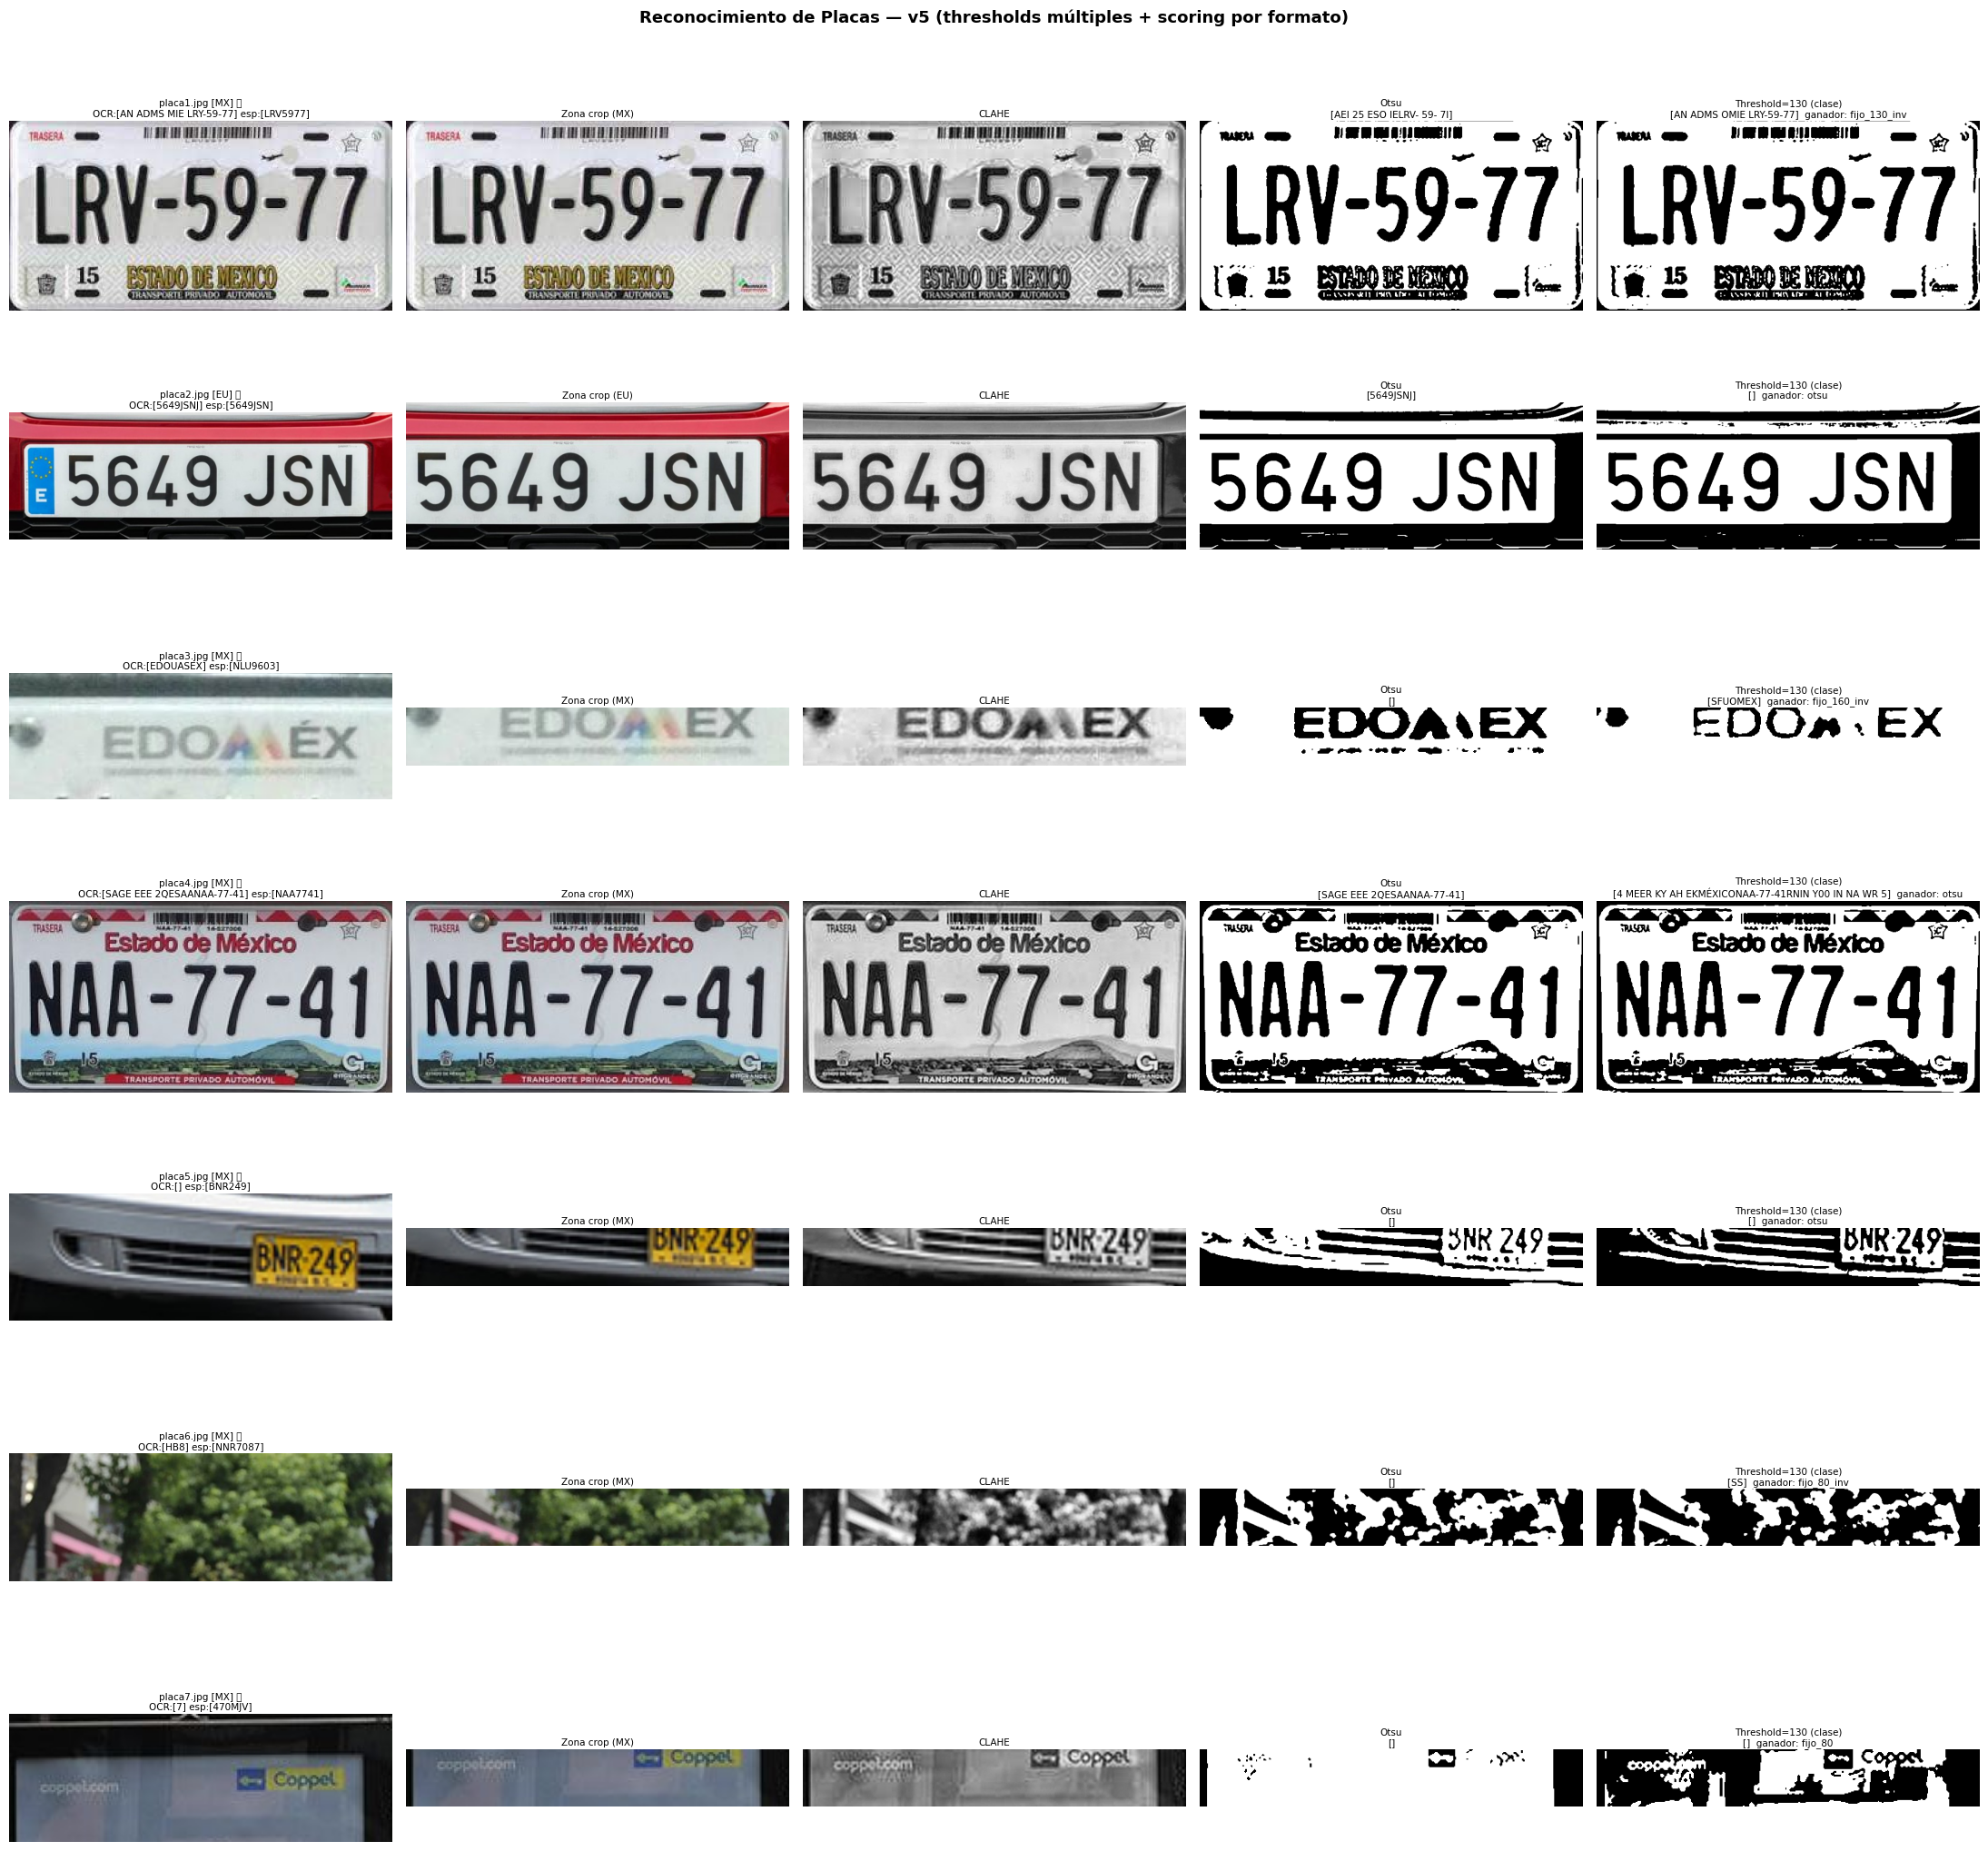

Grilla guardada como output_placas_v5.png ✅


In [12]:
# ═══════════════════════════════════════════════════════════════
# CELDA 6 — Grilla visual comparativa
# ═══════════════════════════════════════════════════════════════
# Columnas: original | zona crop | CLAHE | Otsu | Threshold 130
# (Threshold 130 = el que usa el ejercicio de clase)

n    = len(resultados)
fig, axes = plt.subplots(n, 5, figsize=(22, 3.0 * n))
if n == 1:
    axes = [axes]

for fila, r in enumerate(resultados):
    et = r['etapas']
    gt_texto, _ = GROUND_TRUTH.get(r['imagen'], ('?','?'))
    v_ocr = verificar_ocr(r['texto'], gt_texto)

    # Texto del mejor threshold fijo encontrado
    texto_130 = r['detalle'].get('fijo_130', '')
    score_mejor = r['scores'].get(r['mejor'], 0)

    imgs_row = [
        (et['original'],   True,  f"{r['imagen']} [{r['tipo']}] {v_ocr}\nOCR:[{r['texto']}] esp:[{gt_texto}]"),
        (et['zona'],       True,  f"Zona crop ({r['tipo']})"),
        (et['clahe'],      False, 'CLAHE'),
        (et['bin_otsu'],   False, f"Otsu\n[{r['detalle']['otsu']}]"),
        (et['fijo_130'],   False, f"Threshold=130 (clase)\n[{texto_130}]  ganador: {r['mejor']}"),
    ]

    for col, (img, es_color, titulo) in enumerate(imgs_row):
        ax = axes[fila][col]
        ax.imshow(img) if es_color else ax.imshow(img, cmap='gray')
        ax.set_title(titulo, fontsize=7.5, pad=3)
        ax.axis('off')

plt.suptitle('Reconocimiento de Placas — v5 (thresholds múltiples + scoring por formato)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('output_placas_v5.png', dpi=120, bbox_inches='tight')
plt.show()
print('Grilla guardada como output_placas_v5.png ✅')
